In [ ]:
# Notebook: TFT pipeline (start-to-finish) with GMM clustering + labeled clusters
# - Starts from loading CSV
# - Recomputes biller aggregates and GMM clustering (same approach as LightGBM notebook)
# - Maps clusters to 4 readable labels
# - Prepares TimeSeriesDataSet for txn_value and (optionally) txn_amount
# - Trains TemporalFusionTransformer for txn_value
# - Evaluates and plots predictions

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib
import matplotlib.pyplot as plt

In [2]:
# pytorch-forecasting imports
import pytorch_lightning as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

c:\Users\user\Documents\imp_1\tftenv\lib\site-packages\pytorch_forecasting\models\base_model.py:24: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [4]:
# -----------------------------
# CONFIG
# -----------------------------
CSV_PATH = 'India_upi_like_biller_realistic.csv'
MODEL_DIR = 'models_tft_v2'
N_CLUSTERS = 4
TEST_DAYS = 90
LOOKBACK_DAYS = 180
MAX_ENCODER = 30
MAX_PRED = 7
BATCH_SIZE = 64
EPOCHS = 10
RANDOM_STATE = 42
os.makedirs(MODEL_DIR, exist_ok=True)

In [5]:
# -----------------------------
# LOAD
# -----------------------------
df = pd.read_csv(CSV_PATH, parse_dates=['txn_date'])
df['biller_id'] = df['biller_id'].astype(str)
df = df.sort_values(['biller_id','txn_date']).reset_index(drop=True)

In [6]:
# -----------------------------
# Recompute biller aggregates (same as LightGBM notebook)
# -----------------------------


def compute_biller_aggs(df, lookback_days=LOOKBACK_DAYS, ref_date=None):
    if ref_date is None:
        ref_date = df['txn_date'].max()
    start_date = ref_date - pd.Timedelta(days=lookback_days)
    df_hist = df[(df['txn_date'] >= start_date) & (df['txn_date'] <= ref_date)].copy()
    ag = df_hist.groupby('biller_id').agg(
        avg_txn_value_per_day=('txn_value','mean'),
        avg_txn_amount_per_day=('txn_amount','mean'),
        std_txn_value=('txn_value','std'),
        std_txn_amount=('txn_amount','std')
    ).fillna(0).reset_index()
    ag['avg_ticket_size'] = (ag['avg_txn_amount_per_day'] / (ag['avg_txn_value_per_day'] + 1e-9)).clip(0, None)
    ag['coeff_var_value'] = ag['std_txn_value'] / (ag['avg_txn_value_per_day'] + 1e-9)
    return ag


biller_aggs = compute_biller_aggs(df)

In [7]:
# -----------------------------
# Fit GMM and label clusters into quadrants
# -----------------------------
features = ['avg_txn_value_per_day','avg_txn_amount_per_day']
X = biller_aggs[features].values
scaler = StandardScaler().fit(X)
X_s = scaler.transform(X)


gmm = GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_STATE).fit(X_s)
labels = gmm.predict(X_s)
probs = gmm.predict_proba(X_s)


biller_aggs['gmm_cluster'] = labels
for i in range(probs.shape[1]):
    biller_aggs[f'prob_{i}'] = probs[:,i]


# map clusters to quadrant labels via center positions relative to medians
centers = scaler.inverse_transform(gmm.means_)
centers_df = pd.DataFrame(centers, columns=features)
median_value = biller_aggs['avg_txn_value_per_day'].median()
median_amount = biller_aggs['avg_txn_amount_per_day'].median()


def quadrant_label_from_center(r):
    if r['avg_txn_value_per_day'] >= median_value and r['avg_txn_amount_per_day'] >= median_amount:
        return 'HighValue-HighAmount'
    if r['avg_txn_value_per_day'] >= median_value and r['avg_txn_amount_per_day'] < median_amount:
        return 'HighValue-LowAmount'
    if r['avg_txn_value_per_day'] < median_value and r['avg_txn_amount_per_day'] >= median_amount:
        return 'LowValue-HighAmount'
    return 'LowValue-LowAmount'


cluster_label_map = {}
for i,row in centers_df.iterrows():
    cluster_label_map[int(row.name)] = quadrant_label_from_center(row)


biller_aggs['cluster_label'] = biller_aggs['gmm_cluster'].map(cluster_label_map)


# save clustering artifacts
biller_aggs.to_csv(os.path.join(MODEL_DIR,'biller_clusters_summary.csv'), index=False)
joblib.dump({'gmm':gmm,'scaler':scaler,'cluster_label_map':cluster_label_map}, os.path.join(MODEL_DIR,'clustering_artifacts.joblib'))


print('Clusters labeled:')
print(biller_aggs['cluster_label'].value_counts())

Clusters labeled:
HighValue-HighAmount    65
LowValue-LowAmount      35
Name: cluster_label, dtype: int64


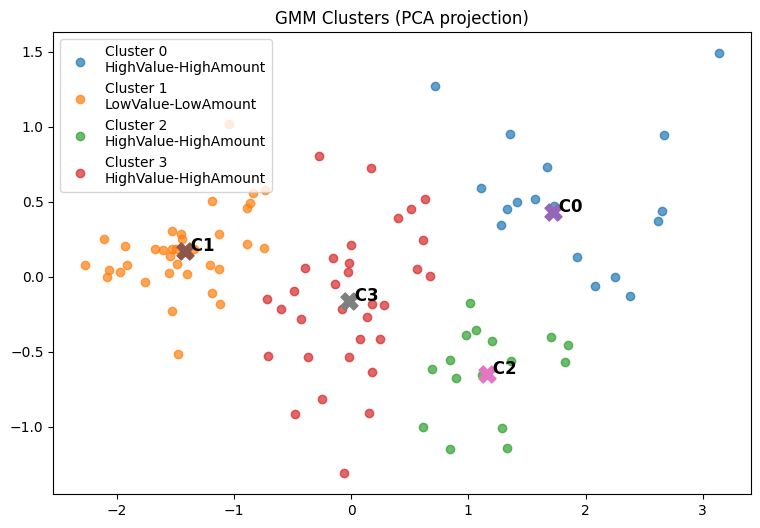

In [8]:
# -----------------------------
# Visualize clusters (PCA + simple plots)
# -----------------------------
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
proj = pca.fit_transform(X_s)
plt.figure(figsize=(9,6))
for c in sorted(biller_aggs['gmm_cluster'].unique()):
    m = biller_aggs['gmm_cluster']==c
    plt.scatter(proj[m,0], proj[m,1], label=f'Cluster {c}\n{cluster_label_map[c]}', alpha=0.7)
centers_proj = pca.transform(gmm.means_)
for i,c in enumerate(centers_proj):
    plt.scatter(c[0], c[1], marker='X', s=150)
    plt.text(c[0], c[1], f' C{i} ', fontsize=12, fontweight='bold')
plt.legend(); plt.title('GMM Clusters (PCA projection)'); plt.show()

In [9]:
# -----------------------------
# Prepare df for TFT: merge cluster_label + time features + lags
# -----------------------------
df_tft = df.merge(biller_aggs[['biller_id','gmm_cluster','cluster_label','avg_ticket_size']], on='biller_id', how='left')
df_tft['time_idx'] = (df_tft['txn_date'] - df_tft['txn_date'].min()).dt.days
df_tft['dow'] = df_tft['txn_date'].dt.dayofweek
df_tft['month'] = df_tft['txn_date'].dt.month


# create lags: TFT needs some history for encoder
for lag in [1,7]:
    df_tft[f'v_lag_{lag}'] = df_tft.groupby('biller_id')['txn_value'].shift(lag)


# drop NA rows which lack lag history
min_history = MAX_ENCODER if 'MAX_ENCODER' in globals() else 30
# ensure at least v_lag_1 and v_lag_7 exist
df_tft = df_tft.dropna(subset=[f'v_lag_1', f'v_lag_7']).copy()

In [11]:
# -----------------------------
# Build TimeSeriesDataSet for txn_value
# -----------------------------
from pytorch_forecasting import Baseline


training_cutoff = df_tft['time_idx'].max() - MAX_PRED - 30
df_tft["gmm_cluster"] = df_tft["gmm_cluster"].astype(str) #added later

training = TimeSeriesDataSet(
df_tft[df_tft['time_idx'] <= training_cutoff],
time_idx='time_idx',
target='txn_value',
group_ids=['biller_id'],
max_encoder_length=MAX_ENCODER,
max_prediction_length=MAX_PRED,
static_categoricals=['gmm_cluster'],
static_reals=['avg_ticket_size'],
time_varying_known_reals=['time_idx','month','dow'],
time_varying_unknown_reals=['txn_value','v_lag_1','v_lag_7'],
target_normalizer=GroupNormalizer(groups=['biller_id'])
)


validation = TimeSeriesDataSet.from_dataset(training, df_tft, predict=True, stop_randomization=True)


train_loader = training.to_dataloader(train=True, batch_size=BATCH_SIZE, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

In [12]:
# -----------------------------
# Train TFT
# -----------------------------
pl.seed_everything(RANDOM_STATE)
model = TemporalFusionTransformer.from_dataset(
training,
learning_rate=0.03,
hidden_size=16,
attention_head_size=1,
dropout=0.1,
hidden_continuous_size=8,
loss=QuantileLoss()
)


trainer = pl.Trainer(max_epochs=EPOCHS, accelerator='auto')
trainer.fit(model, train_loader, val_loader)
trainer.save_checkpoint(os.path.join(MODEL_DIR,'tft_txn_value.ckpt'))

Global seed set to 42
c:\Users\user\Documents\imp_1\tftenv\lib\site-packages\pytorch_lightning\utilities\parsing.py:262: UserWarning: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
  rank_zero_warn(
c:\Users\user\Documents\imp_1\tftenv\lib\site-packages\pytorch_lightning\utilities\parsing.py:262: UserWarning: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
  rank_zero_warn(
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Missing logger folder: c:\Users\user\Documents\imp_1\tftenv\lightning_logs

   | Name                               | Type                            | Params
----------------------------------------

c:\Users\user\Documents\imp_1\tftenv\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 24 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
c:\Users\user\Documents\imp_1\tftenv\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 24 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Epoch 9: 100%|██████████| 447/447 [00:40<00:00, 11.03it/s, loss=6.75e+03, v_num=0, train_loss_step=8.35e+3, val_loss=1.25e+3, train_loss_epoch=8.28e+3]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 447/447 [00:40<00:00, 11.02it/s, loss=6.75e+03, v_num=0, train_loss_step=8.35e+3, val_loss=1.25e+3, train_loss_epoch=8.28e+3]


TFT (approx) MAE: 6685.430043422155 RMSE: 6854.356804439026


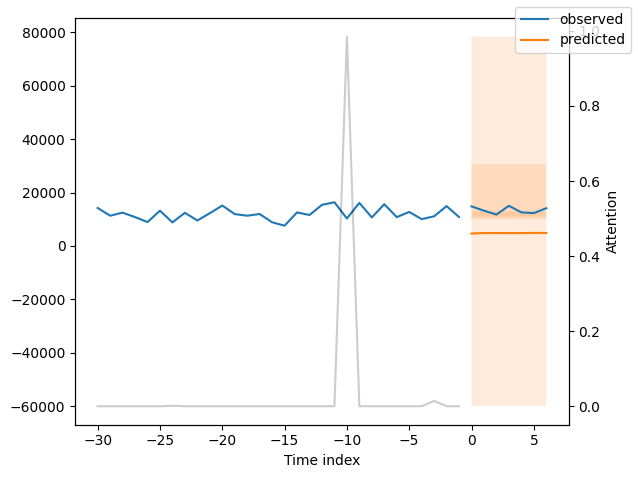

TFT notebook completed. Artifacts saved to models_tft_v2


In [14]:
# -----------------------------
# Evaluate: predict on validation and compute simple RMSE/MAE aggregated
# -----------------------------
raw_preds, x = model.predict(val_loader, mode='raw', return_x=True)
# For numeric metrics use the `predict` with mode='prediction' to get point forecasts
preds = model.predict(val_loader, mode='prediction')


# preds is an array (num_samples, prediction_length)
# we will compute per-sample MAE against true targets available in x


# assemble true and predicted arrays for first dimension
true_vals = x['decoder_target'].detach().cpu().numpy() # shape: (batch_size, prediction_length)
pred_vals = preds


# compute simple RMSE and MAE across validation batches (approximate)
from sklearn.metrics import mean_absolute_error
maes = []
rmses = []
for i in range(true_vals.shape[0]):
    t = true_vals[i]
    p = pred_vals[i]
    t = t.astype(float)
    p = p.detach().cpu().numpy()
    maes.append(mean_absolute_error(t, p))
    rmses.append(np.sqrt(np.mean((t-p)**2)))


print('TFT (approx) MAE:', np.mean(maes), 'RMSE:', np.mean(rmses))


# visualize first sample prediction
fig = model.plot_prediction(x, raw_preds, idx=0)
plt.show()


print('TFT notebook completed. Artifacts saved to', MODEL_DIR)